In [1]:
!pip install -q --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git

from google.colab import drive
drive.mount("/content/drive")

import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from aeroguard.donnees_ml import preparer_xy
from aeroguard.evaluation import ajouter_au_leaderboard, metriques

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

modeles = {
    "bete": DummyClassifier(strategy="most_frequent"),
    "copieur_knn": make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    "logistique": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
}
for m in modeles.values():
    m.fit(X_train, y_train)
print("3 modèles entraînés ✅")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive
3 modèles entraînés ✅


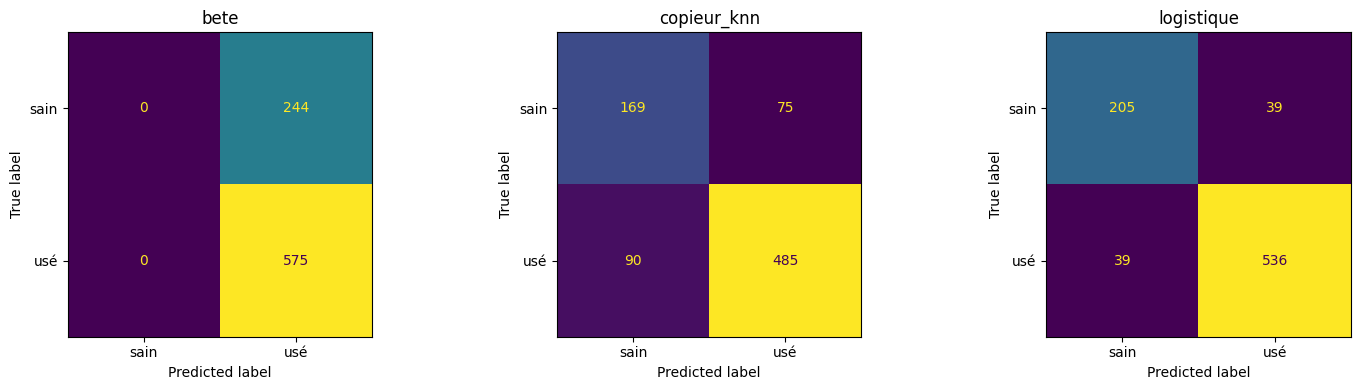

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nom, m) in zip(axes, modeles.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_val, m.predict(X_val), display_labels=["sain", "usé"], ax=ax, colorbar=False
    )
    ax.set_title(nom)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/23_matrices_confusion.png", dpi=120)
plt.show()

In [3]:
from sklearn.metrics import classification_report

print(classification_report(y_val, modeles["logistique"].predict(X_val),
                            target_names=["sain", "usé"], digits=3))

              precision    recall  f1-score   support

        sain      0.840     0.840     0.840       244
         usé      0.932     0.932     0.932       575

    accuracy                          0.905       819
   macro avg      0.886     0.886     0.886       819
weighted avg      0.905     0.905     0.905       819



In [4]:
lignes = []
for nom, m in modeles.items():
    probas = m.predict_proba(X_val)[:, 1]
    scores = metriques(y_val, m.predict(X_val), probas=probas)
    lignes.append({"modele": nom, **scores})
tableau = pd.DataFrame(lignes).set_index("modele").round(3)
tableau

,precision,rappel,f1,f1_macro,vn,fp,fn,vp,pr_auc
modele,,,,,,,,,
bete,0.702,1.000,0.825,0.412,0,244,0,575,0.702
copieur_knn,0.866,0.843,0.855,0.763,169,75,90,485,0.903
logistique,0.932,0.932,0.932,0.886,205,39,39,536,0.987


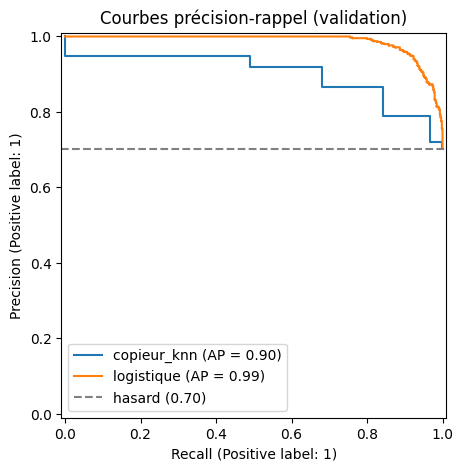

In [5]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(7, 5))
for nom in ["copieur_knn", "logistique"]:
    PrecisionRecallDisplay.from_predictions(
        y_val, modeles[nom].predict_proba(X_val)[:, 1], name=nom, ax=ax
    )
ax.axhline(y_val.mean(), color="gray", linestyle="--", label=f"hasard ({y_val.mean():.2f})")
ax.legend(); ax.set_title("Courbes précision-rappel (validation)")
plt.savefig(f"{DOSSIER}/results/figures/23_courbes_pr.png", dpi=120)
plt.show()

In [6]:
LEADERBOARD = f"{DOSSIER}/results/leaderboard.csv"
if os.path.exists(LEADERBOARD):
    os.remove(LEADERBOARD)  # on repart de zéro avec les nouvelles colonnes

for nom, ligne in tableau.iterrows():
    colonnes = ["f1_macro", "pr_auc", "rappel", "precision", "f1", "fp", "fn"]
    ajouter_au_leaderboard(LEADERBOARD, nom, ligne[colonnes].to_dict())

pd.read_csv(LEADERBOARD).sort_values("f1_macro", ascending=False)

,modele,f1_macro,pr_auc,rappel,precision,f1,fp,fn
2,logistique,0.886,0.987,0.932,0.932,0.932,39.0,39.0
1,copieur_knn,0.763,0.903,0.843,0.866,0.855,75.0,90.0
0,bete,0.412,0.702,1.000,0.702,0.825,244.0,0.0
